In [2]:
%matplotlib widget
import mpl_interactions as pli

In [3]:
#%% Demo 4: Simple Image reconstruction
#
#
# This demo will show how a simple image reconstruction can be performed,
# by using OS-SART and FDK
#
# --------------------------------------------------------------------------
# --------------------------------------------------------------------------
# This file is part of the TIGRE Toolbox
#
# Copyright (c) 2015, University of Bath and
#                     CERN-European Organization for Nuclear Research
#                     All rights reserved.
#
# License:            Open Source under BSD.
#                     See the full license at
#                     https://github.com/CERN/TIGRE/blob/master/LICENSE
#
# Contact:            tigre.toolbox@gmail.com
# Codes:              https://github.com/CERN/TIGRE/
# Coded by:           Ander Biguri
# --------------------------------------------------------------------------
#%%Initialize
import tigre
import numpy as np
from tigre.utilities import sample_loader
from tigre.utilities import CTnoise
import tigre.algorithms as algs


In [4]:

#%% Geometry
geo = tigre.geometry_default(high_resolution=False)

print(geo)

#%% Load data and generate projections
# define angles
angles = np.linspace(0, 2 * np.pi, 100)
# Load thorax phatom data
head = sample_loader.load_head_phantom(geo.nVoxel)
# generate projections
projections = tigre.Ax(head, geo, angles)
# add noise
noise_projections = CTnoise.add(projections, Poisson=1e5, Gaussian=np.array([0, 10]))

#%% Reconstruct image using OS-SART and FDK


TIGRE parameters
-----
Geometry parameters
Distance from source to detector (DSD) = 1536.0 mm
Distance from source to origin (DSO)= 1000.0 mm
-----
Detector parameters
Number of pixels (nDetector) = [128 128]
Size of each pixel (dDetector) = [3.2 3.2] mm
Total size of the detector (sDetector) = [409.6 409.6] mm
-----
Image parameters
Number of voxels (nVoxel) = [64 64 64]
Total size of the image (sVoxel) = [256 256 256] mm
Size of each voxel (dVoxel) = [4. 4. 4.] mm
-----
Offset correction parameters
Offset of image from origin (offOrigin) = [0 0 0] mm
Offset of detector (offDetector) = [0 0] mm
-----
Auxillary parameters
Samples per pixel of forward projection (accuracy) = 0.5
-----
Rotation of the Detector (rotDetector) = [0 0 0] rad


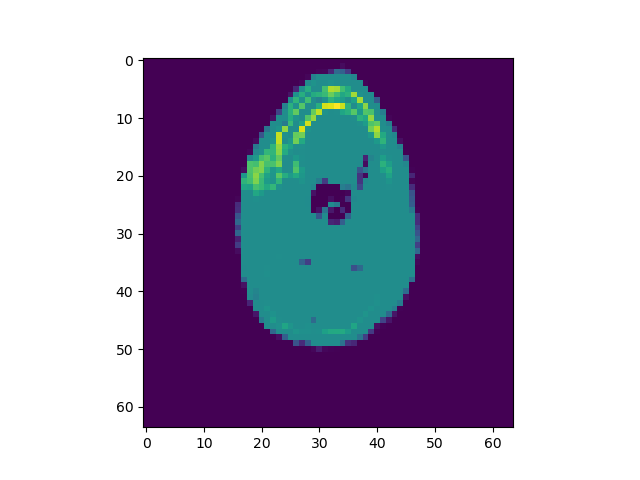

In [8]:
import matplotlib.pyplot as plt

plt.figure()
pli.hyperslicer(head)

In [ ]:

# FDK
imgFDK = algs.fdk(noise_projections, geo, angles)
# OS-SART

niter = 50
imgOSSART = algs.ossart(noise_projections, geo, angles, niter)

#%% Show the results
tigre.plotimg(np.concatenate([imgFDK, imgOSSART], axis=1), dim="z")
